In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
DATA_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/data"

data_df = pd.read_csv(f"{DATA_PATH}/Excel table survival analysis.csv", sep="\t", encoding="utf-8")
data_df.head()

,Bday,OPDate,Sex,Zn HIPEC,Age,Tumor,Histo,T,N,M,...,CC,Tod Datum,Overall survival,Overall survival (months),Rezidiv,Lok Rezidiv,Datum Rezidiv,Recurrence-free survival,Recurrence-free survival (months),SF Grund
0,2/25/1991,3/10/2008,2,1,17,1,3,4,2,1,...,1,8/16/2008,"0 years, 5 months, 6 days",5.20,3,1,8/12/2008,"0 years, 5 months, 2 days",5.07,0
1,7/17/1993,7/14/2015,1,1,21,1,3,4,1,1,...,0,5/6/2018,"2 years, 9 months, 22 days",33.72,0,1,12/22/2016,"1 years, 5 months, 8 days",17.26,0
2,6/8/1995,11/23/2018,2,1,23,4,2,3,1,1,...,1,99,99,NaN,3,1,6/22/2022,"3 years, 6 months, 30 days",42.99,0
3,9/2/1979,11/15/2005,1,1,26,10,1,99,99,1,...,0,5/11/2009,"3 years, 5 months, 26 days",41.85,0,1.8,4/12/2006,"0 years, 4 months, 28 days",4.92,0
4,11/18/1990,12/29/2017,1,1,27,3,3,4,2,1,...,0,11/3/2019,"1 years, 10 months, 5 days",22.16,0,1,7/19/2018,"0 years, 6 months, 20 days",6.66,0


In [3]:
cols_to_use = [
    "Bday", "OPDate", "Sex", "Age", "Tumor","sPCI", "pPCI", "Tod Datum", "Datum Rezidiv"
]

reduc_df = data_df[cols_to_use].copy()
reduc_df.head()

,Bday,OPDate,Sex,Age,Tumor,sPCI,pPCI,Tod Datum,Datum Rezidiv
0,2/25/1991,3/10/2008,2,17,1,26,22,8/16/2008,8/12/2008
1,7/17/1993,7/14/2015,1,21,1,5,3,5/6/2018,12/22/2016
2,6/8/1995,11/23/2018,2,23,4,15,6,99,6/22/2022
3,9/2/1979,11/15/2005,1,26,10,15,6,5/11/2009,4/12/2006
4,11/18/1990,12/29/2017,1,27,3,18,4,11/3/2019,7/19/2018


In [4]:
reduc_df["Bday"] = pd.to_datetime(reduc_df["Bday"], errors="coerce")
reduc_df["OPDate"] = pd.to_datetime(reduc_df["OPDate"], errors="coerce")
reduc_df["Tod Datum"] = pd.to_datetime(reduc_df["Tod Datum"], errors="coerce")
reduc_df["Datum Rezidiv"] = pd.to_datetime(reduc_df["Datum Rezidiv"], errors="coerce")
reduc_df.head()

,Bday,OPDate,Sex,Age,Tumor,sPCI,pPCI,Tod Datum,Datum Rezidiv
0,1991-02-25,2008-03-10,2,17,1,26,22,2008-08-16,2008-08-12
1,1993-07-17,2015-07-14,1,21,1,5,3,2018-05-06,2016-12-22
2,1995-06-08,2018-11-23,2,23,4,15,6,NaT,2022-06-22
3,1979-09-02,2005-11-15,1,26,10,15,6,2009-05-11,2006-04-12
4,1990-11-18,2017-12-29,1,27,3,18,4,2019-11-03,2018-07-19


In [5]:
reduc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Bday           285 non-null    datetime64[ns]
 1   OPDate         285 non-null    datetime64[ns]
 2   Sex            285 non-null    int64         
 3   Age            285 non-null    int64         
 4   Tumor          285 non-null    int64         
 5   sPCI           285 non-null    int64         
 6   pPCI           285 non-null    int64         
 7   Tod Datum      131 non-null    datetime64[ns]
 8   Datum Rezidiv  263 non-null    datetime64[ns]
dtypes: datetime64[ns](4), int64(5)
memory usage: 20.2 KB


In [6]:
# Compute different types of correlation between sPCI and pPCI
from scipy.stats import pearsonr, spearmanr, kendalltau

# Remove NaN values for correlation calculations
clean_data = reduc_df[['sPCI', 'pPCI']].dropna()

# Pearson correlation (linear relationship)
pearson_corr, pearson_pval = pearsonr(clean_data['sPCI'], clean_data['pPCI'])

# Spearman correlation (monotonic relationship, rank-based)
spearman_corr, spearman_pval = spearmanr(clean_data['sPCI'], clean_data['pPCI'])

# Kendall's tau (rank correlation, robust to outliers)
kendall_corr, kendall_pval = kendalltau(clean_data['sPCI'], clean_data['pPCI'])

print("Correlation Analysis: sPCI vs pPCI")
print("="*50)
print(f"Sample size (non-missing): {len(clean_data)}")
print()
print(f"Pearson Correlation:  {pearson_corr:.4f} (p-value: {pearson_pval:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")
print(f"Kendall's Tau:        {kendall_corr:.4f} (p-value: {kendall_pval:.4e})")

Correlation Analysis: sPCI vs pPCI
Sample size (non-missing): 285

Pearson Correlation:  0.7357 (p-value: 8.3830e-50)
Spearman Correlation: 0.7771 (p-value: 7.4181e-59)
Kendall's Tau:        0.6151 (p-value: 3.5523e-50)


In [7]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

In [8]:
reduc_df["Sex"] = reduc_df["Sex"] - 1
reduc_df.describe()

,Bday,OPDate,Sex,Age,Tumor,sPCI,pPCI,Tod Datum,Datum Rezidiv
count,285,285,285.00000,285.000000,285.000000,285.000000,285.000000,131,263
mean,1959-06-05 17:20:50.526315776,2013-12-02 20:37:53.684210432,0.60000,54.007018,4.024561,15.831579,9.792982,2017-05-14 12:16:29.312977152,2014-11-08 20:59:18.935361280
min,1932-09-29 00:00:00,2005-06-23 00:00:00,0.00000,17.000000,1.000000,1.000000,0.000000,2007-01-08 00:00:00,2005-10-31 00:00:00
25%,1949-08-06 00:00:00,2011-01-11 00:00:00,0.00000,47.000000,1.000000,9.000000,5.000000,2015-03-04 00:00:00,2011-11-28 00:00:00
50%,1959-11-03 00:00:00,2013-09-24 00:00:00,1.00000,55.000000,4.000000,15.000000,9.000000,2017-07-28 00:00:00,2014-10-08 00:00:00
75%,1967-05-10 00:00:00,2016-12-20 00:00:00,1.00000,63.000000,6.000000,22.000000,14.000000,2019-10-26 12:00:00,2017-08-28 00:00:00
max,1995-06-08 00:00:00,2021-08-12 00:00:00,1.00000,79.000000,19.000000,39.000000,28.000000,2023-03-18 00:00:00,2023-06-15 00:00:00
std,NaN,NaN,0.49076,11.664317,3.525974,9.024988,5.983188,NaN,NaN


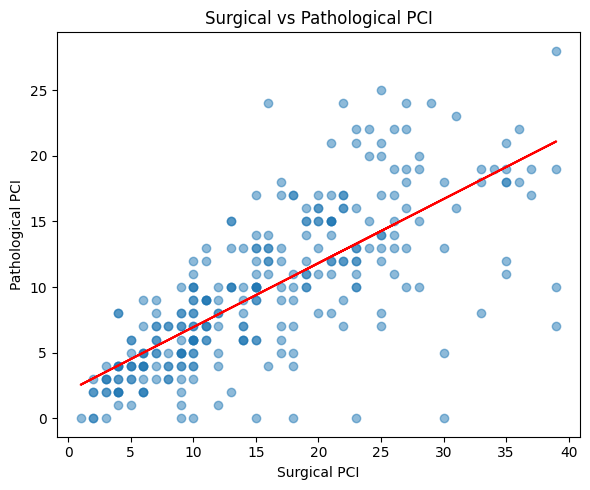

In [9]:
# ── 1. Scatterplot: surgical vs pathological PCI ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reduc_df["sPCI"], reduc_df["pPCI"], alpha=0.5)
z = np.polyfit(reduc_df["sPCI"], reduc_df["pPCI"], 1)
ax.plot(reduc_df["sPCI"], np.poly1d(z)(reduc_df["sPCI"]), color="red")
ax.set_xlabel("Surgical PCI")
ax.set_ylabel("Pathological PCI")
ax.set_title("Surgical vs Pathological PCI")
plt.tight_layout()
plt.show()

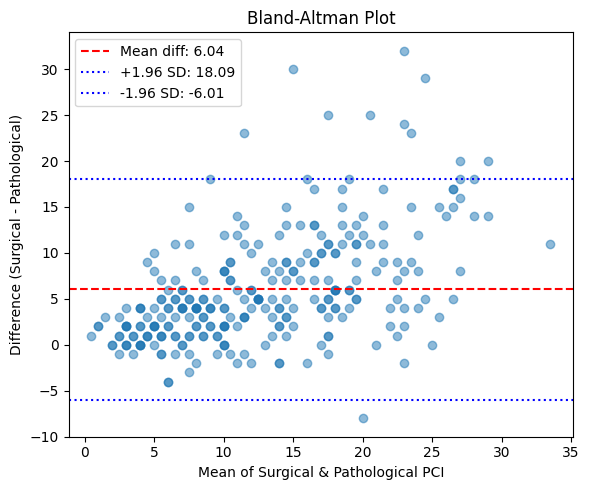

In [10]:
# ── 2. Bland-Altman plot ──────────────────────────────────────────────────────
mean_pci  = (reduc_df["sPCI"] + reduc_df["pPCI"]) / 2
diff_pci  = reduc_df["sPCI"] - reduc_df["pPCI"]
md        = diff_pci.mean()
sd        = diff_pci.std()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mean_pci, diff_pci, alpha=0.5)
ax.axhline(md,        color="red",   linestyle="--", label=f"Mean diff: {md:.2f}")
ax.axhline(md + 1.96*sd, color="blue", linestyle=":", label=f"+1.96 SD: {md + 1.96*sd:.2f}")
ax.axhline(md - 1.96*sd, color="blue", linestyle=":", label=f"-1.96 SD: {md - 1.96*sd:.2f}")
ax.set_xlabel("Mean of Surgical & Pathological PCI")
ax.set_ylabel("Difference (Surgical - Pathological)")
ax.set_title("Bland-Altman Plot")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── 1. Compute survival time (in months from surgery to death/censoring) ───────
# For patients with a death date → time to death
# For patients without → time to last known contact (use today or a study end date)

STUDY_END = pd.Timestamp("2023-07-31")  # adjust to actual study end date

reduc_df["death_date"] = reduc_df["Tod Datum"]

# Status: 1 = died, 0 = censored
reduc_df["status"] = reduc_df["death_date"].notna().astype(int)

# End date: death date if known, otherwise study end date
#reduc_df["end_date"] = reduc_df["death_date"].fillna(STUDY_END)

# censoring date
reduc_df["end_date"] = reduc_df["Tod Datum"].fillna(reduc_df["Datum Rezidiv"]).fillna(STUDY_END)

# Survival time in months
reduc_df["time"] = (reduc_df["end_date"] - reduc_df["OPDate"]).dt.days / 30.44

# ── 2. Sanity checks ───────────────────────────────────────────────────────────
print("Negative times:", (reduc_df["time"] <= 0).sum())   # should be 0
print("Status counts:\n", reduc_df["status"].value_counts())
print("\nSurvival time summary:")
print(reduc_df["time"].describe())


Negative times: 0
Status counts:
 status
0    154
1    131
Name: count, dtype: int64

Survival time summary:
count    285.000000
mean      22.630196
std       24.557890
min        0.394218
25%        6.603154
50%       13.304862
75%       31.011827
max      159.264126
Name: time, dtype: float64


In [12]:
# If Tumor is an integer code (1, 2, 3...) treat as categorical
reduc_df = pd.get_dummies(reduc_df, columns=["Tumor"], drop_first=True)
cancer_dummies = [c for c in reduc_df.columns if c.startswith("Tumor_")]

In [13]:
reduc_df.describe()

,Bday,OPDate,Sex,Age,sPCI,pPCI,Tod Datum,Datum Rezidiv,death_date,status,end_date,time
count,285,285,285.00000,285.000000,285.000000,285.000000,131,263,131,285.000000,285,285.000000
mean,1959-06-05 17:20:50.526315776,2013-12-02 20:37:53.684210432,0.60000,54.007018,15.831579,9.792982,2017-05-14 12:16:29.312977152,2014-11-08 20:59:18.935361280,2017-05-14 12:16:29.312977152,0.459649,2015-10-22 17:20:50.526315776,22.630196
min,1932-09-29 00:00:00,2005-06-23 00:00:00,0.00000,17.000000,1.000000,0.000000,2007-01-08 00:00:00,2005-10-31 00:00:00,2007-01-08 00:00:00,0.000000,2005-10-31 00:00:00,0.394218
25%,1949-08-06 00:00:00,2011-01-11 00:00:00,0.00000,47.000000,9.000000,5.000000,2015-03-04 00:00:00,2011-11-28 00:00:00,2015-03-04 00:00:00,0.000000,2012-08-12 00:00:00,6.603154
50%,1959-11-03 00:00:00,2013-09-24 00:00:00,1.00000,55.000000,15.000000,9.000000,2017-07-28 00:00:00,2014-10-08 00:00:00,2017-07-28 00:00:00,0.000000,2016-01-12 00:00:00,13.304862
75%,1967-05-10 00:00:00,2016-12-20 00:00:00,1.00000,63.000000,22.000000,14.000000,2019-10-26 12:00:00,2017-08-28 00:00:00,2019-10-26 12:00:00,1.000000,2019-04-23 00:00:00,31.011827
max,1995-06-08 00:00:00,2021-08-12 00:00:00,1.00000,79.000000,39.000000,28.000000,2023-03-18 00:00:00,2023-06-15 00:00:00,2023-03-18 00:00:00,1.000000,2023-06-15 00:00:00,159.264126
std,NaN,NaN,0.49076,11.664317,9.024988,5.983188,NaN,NaN,NaN,0.499246,NaN,24.557890


In [14]:
# ── 4. Final model dataframe ──────────────────────────────────────────────────
base_covars = ["Age", "Sex"] + cancer_dummies

df_A = reduc_df[["sPCI"] + base_covars + ["time", "status"]].dropna()
df_B = reduc_df[["pPCI"] + base_covars + ["time", "status"]].dropna()

print(f"\nModel A shape: {df_A.shape}")
print(f"Model B shape: {df_B.shape}")

# ── 5. Quick summary before modeling ─────────────────────────────────────────
print("\nEvents in Model A:", df_A["status"].sum())
print("Events in Model B:", df_B["status"].sum())


Model A shape: (285, 21)
Model B shape: (285, 21)

Events in Model A: 131
Events in Model B: 131


In [15]:
df_A.to_csv(f"{DATA_PATH}/model_A_data.csv", index=False)
df_B.to_csv(f"{DATA_PATH}/model_B_data.csv", index=False)

In [16]:
reduc_df.to_csv(f"{DATA_PATH}/reduced_data.csv", index=False)

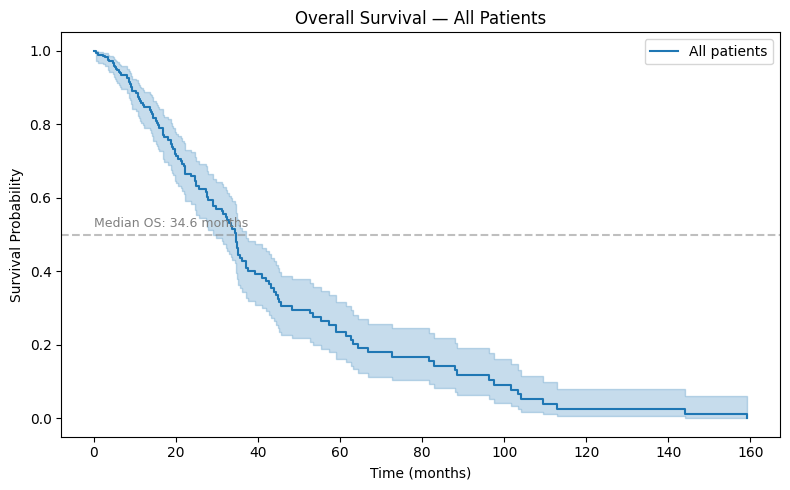

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

kmf = KaplanMeierFitter()

# ── 1. Overall survival curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
kmf.fit(reduc_df["time"], event_observed=reduc_df["status"], label="All patients")
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

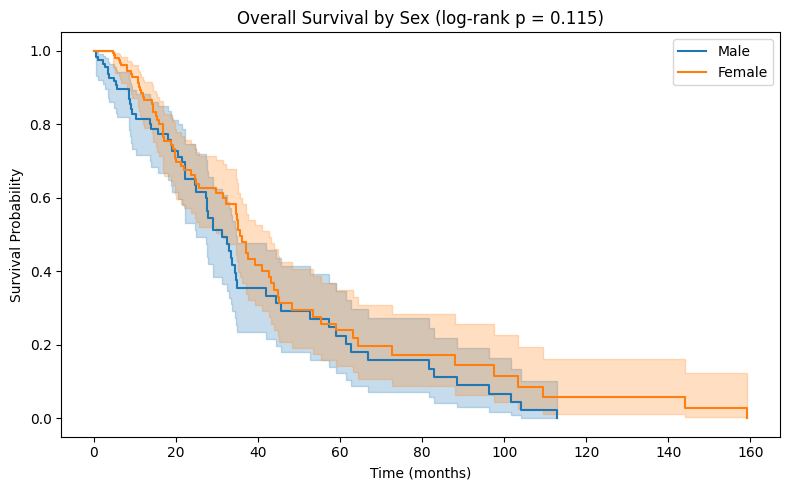

In [18]:
# ── 2. KM by Sex ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
groups = reduc_df.groupby("Sex")
for name, group in groups:
    label = "Female" if name == 1 else "Male"
    kmf.fit(group["time"], event_observed=group["status"], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)

# Log-rank test
lr = logrank_test(
    reduc_df[reduc_df["Sex"] == 0]["time"], reduc_df[reduc_df["Sex"] == 1]["time"],
    event_observed_A=reduc_df[reduc_df["Sex"] == 0]["status"],
    event_observed_B=reduc_df[reduc_df["Sex"] == 1]["status"]
)
ax.set_title(f"Overall Survival by Sex (log-rank p = {lr.p_value:.3f})")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

In [19]:
# log-rank test for sex
lr

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.48 0.11      3.12

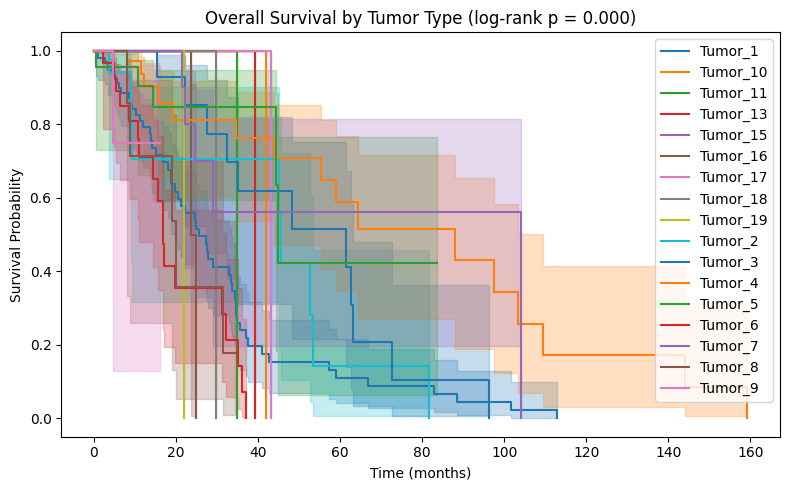

In [20]:
# ── 3. KM by Tumor type ───────────────────────────────────────────────────────
tumor_cols = [c for c in reduc_df.columns if c.startswith("Tumor_")]

# Reconstruct single tumor column for grouping
reduc_df["Tumor_group"] = (
    reduc_df[tumor_cols]
    .idxmax(axis=1)                        # gets e.g. "Tumor_2"
    .where(reduc_df[tumor_cols].any(axis=1), "Tumor_1")  # reference category
)

fig, ax = plt.subplots(figsize=(8, 5))
for grp, gdf in reduc_df.groupby("Tumor_group"):
    kmf.fit(gdf["time"], event_observed=gdf["status"], label=grp)
    kmf.plot_survival_function(ax=ax, ci_show=True)

# Multivariate log-rank test
mlr = multivariate_logrank_test(reduc_df["time"], reduc_df["Tumor_group"], reduc_df["status"])
ax.set_title(f"Overall Survival by Tumor Type (log-rank p = {mlr.p_value:.3f})")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

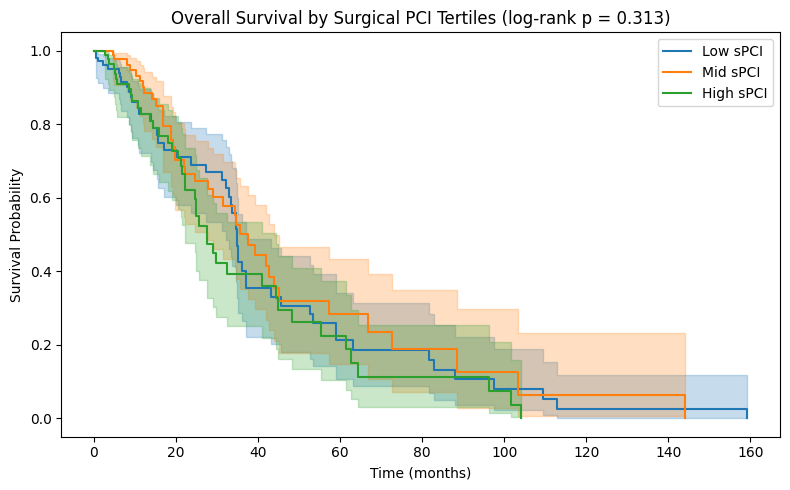

In [21]:
# ── 4. KM by sPCI tertiles ────────────────────────────────────────────────────
reduc_df["sPCI_group"] = pd.qcut(reduc_df["sPCI"], q=3,
                            labels=["Low sPCI", "Mid sPCI", "High sPCI"])

fig, ax = plt.subplots(figsize=(8, 5))
for grp, gdf in reduc_df.groupby("sPCI_group", observed=True):
    kmf.fit(gdf["time"], event_observed=gdf["status"], label=grp)
    kmf.plot_survival_function(ax=ax, ci_show=True)

mlr_s = multivariate_logrank_test(reduc_df["time"], reduc_df["sPCI_group"], reduc_df["status"])
ax.set_title(f"Overall Survival by Surgical PCI Tertiles (log-rank p = {mlr_s.p_value:.3f})")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

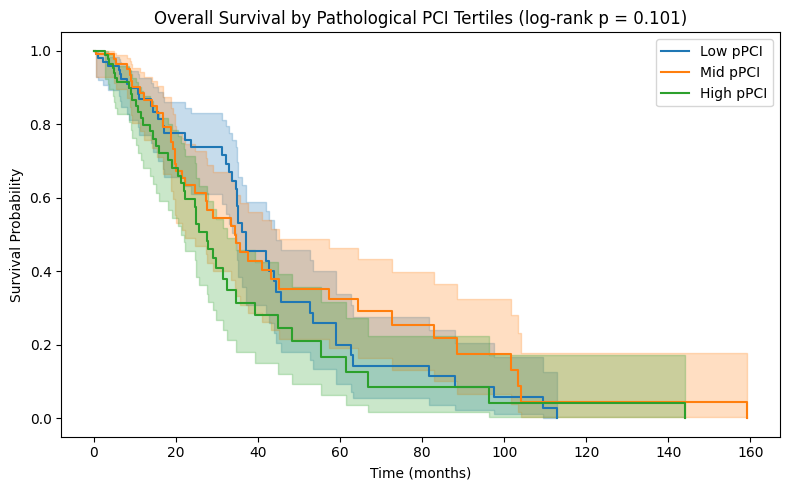

In [22]:
# ── 5. KM by pPCI tertiles ────────────────────────────────────────────────────
reduc_df["pPCI_group"] = pd.qcut(reduc_df["pPCI"], q=3,
                            labels=["Low pPCI", "Mid pPCI", "High pPCI"])

fig, ax = plt.subplots(figsize=(8, 5))
for grp, gdf in reduc_df.groupby("pPCI_group", observed=True):
    kmf.fit(gdf["time"], event_observed=gdf["status"], label=grp)
    kmf.plot_survival_function(ax=ax, ci_show=True)

mlr_p = multivariate_logrank_test(reduc_df["time"], reduc_df["pPCI_group"], reduc_df["status"])
ax.set_title(f"Overall Survival by Pathological PCI Tertiles (log-rank p = {mlr_p.p_value:.3f})")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
plt.tight_layout()
plt.show()

In [23]:
# ── 6. Summary table ──────────────────────────────────────────────────────────
print("\n── Median Survival Times ──────────────────────────────")
for col, label in [("sPCI_group", "Surgical PCI"), ("pPCI_group", "Pathological PCI"),
                   ("Sex", "Sex"), ("Tumor_group", "Tumor")]:
    print(f"\n{label}:")
    for grp, gdf in reduc_df.groupby(col, observed=True):
        kmf.fit(gdf["time"], event_observed=gdf["status"])
        n = len(gdf)
        events = gdf["status"].sum()
        print(f"  {grp}: n={n}, events={events}, median OS={kmf.median_survival_time_:.1f} months")


── Median Survival Times ──────────────────────────────

Surgical PCI:
  Low sPCI: n=103, events=50, median OS=34.8 months
  Mid sPCI: n=94, events=39, median OS=37.5 months
  High sPCI: n=88, events=42, median OS=27.5 months

Pathological PCI:
  Low pPCI: n=98, events=46, median OS=37.0 months
  Mid pPCI: n=98, events=42, median OS=34.3 months
  High pPCI: n=89, events=43, median OS=27.5 months

Sex:
  0: n=114, events=60, median OS=31.3 months
  1: n=171, events=71, median OS=35.6 months

Tumor:
  Tumor_1: n=99, events=54, median OS=25.7 months
  Tumor_10: n=1, events=1, median OS=41.8 months
  Tumor_11: n=3, events=1, median OS=34.8 months
  Tumor_13: n=2, events=1, median OS=39.4 months
  Tumor_15: n=1, events=0, median OS=inf months
  Tumor_16: n=4, events=2, median OS=23.7 months
  Tumor_17: n=2, events=1, median OS=43.2 months
  Tumor_18: n=2, events=1, median OS=29.7 months
  Tumor_19: n=1, events=1, median OS=21.9 months
  Tumor_2: n=18, events=8, median OS=45.7 months
  Tumo

In [24]:
# 1. Print the log-rank p-values you already have
print(f"sPCI log-rank p: {mlr_s.p_value:.4f}")
print(f"pPCI log-rank p: {mlr_p.p_value:.4f}")

# 2. Report 25th percentile survival instead of median
from lifelines.utils import qth_survival_times

for col, label in [("sPCI_group", "Surgical PCI"), ("pPCI_group", "Pathological PCI")]:
    print(f"\n{label} — 25th percentile survival times:")
    for grp, gdf in reduc_df.groupby(col, observed=True):
        kmf.fit(gdf["time"], event_observed=gdf["status"])
        q25 = qth_survival_times(0.75, kmf.survival_function_)  # 75% still alive = 25th pct
        print(f"  {grp}: {q25:.1f} months")

# 3. Report 3-year and 5-year survival probabilities
for col, label in [("sPCI_group", "Surgical PCI"), ("pPCI_group", "Pathological PCI")]:
    print(f"\n{label} — Survival probabilities:")
    for grp, gdf in reduc_df.groupby(col, observed=True):
        kmf.fit(gdf["time"], event_observed=gdf["status"])
        p36  = kmf.predict(36)   # 3-year (36 months)
        p60  = kmf.predict(60)   # 5-year (60 months)
        print(f"  {grp}: 3-yr = {p36:.3f}, 5-yr = {p60:.3f}")


sPCI log-rank p: 0.3133
pPCI log-rank p: 0.1008

Surgical PCI — 25th percentile survival times:
  Low sPCI: 17.1 months
  Mid sPCI: 19.2 months
  High sPCI: 18.0 months

Pathological PCI — 25th percentile survival times:
  Low pPCI: 23.7 months
  Mid pPCI: 19.2 months
  High pPCI: 15.2 months

Surgical PCI — Survival probabilities:
  Low sPCI: 3-yr = 0.424, 5-yr = 0.212
  Mid sPCI: 3-yr = 0.500, 5-yr = 0.283
  High sPCI: 3-yr = 0.393, 5-yr = 0.225

Pathological PCI — Survival probabilities:
  Low pPCI: 3-yr = 0.531, 5-yr = 0.201
  Mid pPCI: 3-yr = 0.452, 5-yr = 0.324
  High pPCI: 3-yr = 0.315, 5-yr = 0.168
